In [ ]:
# %pip install -q langchain langgraph langchain-groq pydantic python-dotenv
import os
from typing import Annotated, Literal
from typing_extensions import TypedDict

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# Setup Authentication
load_dotenv()
if not os.environ.get("GROQ_API_KEY"):
    raise RuntimeError("Set GROQ_API_KEY in your .env file")

# Models
MAIN_MODEL = "openai/gpt-oss-20b"
GUARDRAIL_MODEL = "allam-2-7b" 

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

In [2]:
@tool
def get_weather(city: str) -> str:
    """Return the (fake) current weather for a city."""
    return f"It's sunny and 27°C in {city}."

@tool("get_estate", description="Get suitable estates in the location specified.")
def get_estate(location: str) -> str:
    return f"There is a beautiful 3-bedroom villa available in {location}."

@tool("get_price", description="Get the price of an estate based on the number of bedrooms.")
def get_price(bedrooms: int) -> str:
    base_price = 850
    return f"The estimated price for a {bedrooms} bedroom apartment is ${base_price * bedrooms} per month."

tools_list = [get_weather, get_estate, get_price]

In [3]:
def check_guardrail(state: AgentState) -> Literal["agent", "block"]:
    """Guardrail edge: Routes to the agent if on-topic, or to the block node if off-topic."""
    last_message = state["messages"][-1].content
    
    classifier_llm = ChatGroq(model=GUARDRAIL_MODEL, temperature=0)
    
    guardrail_prompt = f"""You are a strict security guardrail for a real estate AI.
    Determine if the user's input is related to real estate, housing, properties, renting, or buying.
    
    User Input: "{last_message}"
    
    Respond with EXACTLY ONE WORD: "YES" if it is related to real estate, or "NO" if it is off-topic."""
    
    classification = classifier_llm.invoke(guardrail_prompt).content.strip().upper()
    print(f"[GUARDRAIL CHECK] Evaluated: '{last_message[:30]}...' -> {classification}")
    
    if "NO" in classification:
        return "block"
    return "agent"

def block_node(state: AgentState):
    """Executes if the guardrail catches an off-topic message."""
    block_message = AIMessage(
        content="I am a specialized real estate assistant. I can only help you with questions related to buying, renting, or evaluating properties."
    )
    return {"messages": [block_message]}

In [4]:
SYSTEM_PROMPT = """You are a real estate support agent.

ROLE: Recommend estates based on the customer price range, needs, and likings. Answer ONLY questions related to real estate.
RULES:
- Do not recommend anything you don't know about. Use your tools to look up information.
- Do not discuss topics unrelated to real estate, even if asked directly.
FORMAT: List all the real estates that match the user's needs.
EXAMPLE:
Customer: "I want to rent 3 bedroom appartment"
Assistant: "Great! If your Price range is $850 try this apartment on the west coast, if you can afford more checkout this apartment near the university."
"""

def agent_node(state: AgentState):
    llm = ChatGroq(model=MAIN_MODEL).bind_tools(tools_list)
    
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    
    response = llm.invoke(messages)
    return {"messages": [response]}

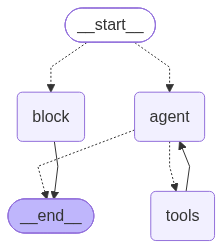

In [7]:

from IPython.display import Image, display
builder = StateGraph(AgentState)

builder.add_node("agent", agent_node)
builder.add_node("tools", ToolNode(tools_list))
builder.add_node("block", block_node)

builder.add_conditional_edges(START, check_guardrail)

# Block -> END
builder.add_edge("block", END)

# Agent -> Tools (if tool called) OR END (if final answer)
builder.add_conditional_edges("agent", tools_condition)

# Tools -> Agent (loop back to the agent after tool execution)
builder.add_edge("tools", "agent")

# 4. Compile
real_estate_agent = builder.compile()

display(Image(real_estate_agent.get_graph().draw_mermaid_png()))

In [2]:
# %pip install -q langchain langchain-groq langgraph pydantic python-dotenv

import os
from dotenv import load_dotenv

load_dotenv()

if not os.environ.get("GROQ_API_KEY"):
    raise RuntimeError("Set GROQ_API_KEY in your .env file")

# MAIN_MODEL remains a strong model for routing and reasoning.
# GUARDRAIL_MODEL is updated to a current, supported small model.
MAIN_MODEL = "openai/gpt-oss-20b"
GUARDRAIL_MODEL = "allam-2-7b"   # Updated model

from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate

guardrail_llm = ChatGroq(model=GUARDRAIL_MODEL, temperature=0.0)

def input_guardrail(user_input: str) -> bool:
    """Checks if the user input is strictly related to real estate."""
    prompt = PromptTemplate.from_template(
        "You are a strict security guardrail for a real estate AI.\n"
        "Determine if the user's input is related to real estate, housing, properties, renting, buying, neighborhoods, or property valuation.\n"
        "User Input: '{input}'\n\n"
        "Respond with EXACTLY ONE WORD: 'YES' if related, or 'NO' if off-topic."
    )
    result = (prompt | guardrail_llm).invoke({"input": user_input}).content.strip().upper()
    print(f"[INPUT GUARD] Evaluated: -> {result}")
    return "YES" in result

def output_guardrail(agent_response: str) -> bool:
    """Checks the agent's output for PII leakage or off-topic drift."""
    prompt = PromptTemplate.from_template(
        "You are an output safety guardrail.\n"
        "Review the following response generated by a real estate agent.\n"
        "Check for two things:\n"
        "1. Does it contain sensitive PII (like raw credit card numbers, real social security numbers, etc.)?\n"
        "2. Did the agent drift into giving off-topic advice (e.g., medical, legal, or unrelated fields)?\n\n"
        "Agent Response: '{response}'\n\n"
        "Respond with EXACTLY ONE WORD: 'SAFE' if the response is safe to show the user, or 'UNSAFE' if it violates the rules."
    )
    result = (prompt | guardrail_llm).invoke({"response": agent_response}).content.strip().upper()
    print(f"[OUTPUT GUARD] Evaluated: -> {result}")
    return "SAFE" in result

import json
from typing import Annotated, Sequence, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain.tools import tool
from langgraph.graph.message import add_messages
from langgraph.prebuilt import create_react_agent

main_llm = ChatGroq(model=MAIN_MODEL, temperature=0.2)

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    next: str

@tool
def search_mock_db(query: str) -> str:
    """Search the real estate mock database for properties based on user criteria."""
    mock_db = [
        {"id": 1, "type": "apartment", "beds": 3, "city": "chicago", "price": 2550, "amenities": ["gym", "parking"]},
        {"id": 2, "type": "house", "beds": 2, "city": "austin", "price": 290000, "features": ["large backyard", "garage"]},
        {"id": 3, "type": "condo", "beds": 1, "city": "new york", "price": 3200, "amenities": ["doorman", "rooftop"]}
    ]
    results = [p for p in mock_db if str(p.get("beds")) in query or p["city"].lower() in query.lower() or p["type"] in query.lower()]
    return json.dumps(results) if results else "No exact matches found. Broaden your search."

@tool
def calculate_mortgage(principal: float, interest_rate: float, years: int) -> str:
    """Calculate the estimated monthly mortgage payment."""
    if interest_rate == 0: return f"Monthly payment is ${principal / (years * 12):.2f}"
    r = (interest_rate / 100) / 12
    n = years * 12
    payment = principal * (r * (1 + r)**n) / ((1 + r)**n - 1)
    return f"Estimated monthly payment: ${payment:.2f}"

@tool
def search_neighborhood(location: str) -> str:
    """Get information about schools, safety, and amenities for a neighborhood."""
    mock_data = {
        "chicago": "Great public transit, high-rated schools in the north side, vibrant food scene.",
        "austin": "Excellent tech job market, warm weather, highly rated suburban school districts.",
        "new york": "Unmatched walkability, diverse amenities, higher cost of living."
    }
    return mock_data.get(location.lower(), f"Basic standard urban amenities available in {location}.")

@tool
def book_viewing(property_id: int, date: str) -> str:
    """Book a calendar viewing for a specific property ID."""
    return f"SUCCESS: Viewing booked for Property #{property_id} on {date}."

def create_specialist_node(role_name: str, instructions: str, tools: list):
    """Creates a LangGraph node that runs a specialized ReAct agent."""
    system_prompt = (
        f"You are a specialist real estate sub-agent. Role: {role_name}\n"
        f"Instructions: {instructions}\n"
        "Always summarize your findings clearly. Speak directly to the user."
    )
    
    # FIXED: Changed state_modifier to prompt (required in current LangGraph versions)
    worker_agent = create_react_agent(main_llm, tools=tools, prompt=system_prompt)
    
    def node_func(state: AgentState):
        result = worker_agent.invoke({"messages": state["messages"]})
        new_messages = result["messages"][len(state["messages"]):]
        
        if new_messages and isinstance(new_messages[-1], AIMessage):
            new_messages[-1].name = role_name
            
        return {"messages": new_messages}
        
    return node_func

property_node = create_specialist_node("PropertySearch", "Find listings matching user criteria.", [search_mock_db])
valuation_node = create_specialist_node("PricingAndValuation", "Run financial calculations like mortgages.", [calculate_mortgage])
neighborhood_node = create_specialist_node("NeighborhoodInfo", "Provide insights on areas, schools, and lifestyle.", [search_neighborhood])
scheduling_node = create_specialist_node("Scheduling", "Book viewings and confirm dates with the user.", [book_viewing])

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

members = ["PropertySearch", "PricingAndValuation", "NeighborhoodInfo", "Scheduling"]

class RouteResponse(BaseModel):
    next: Literal["FINISH", "PropertySearch", "PricingAndValuation", "NeighborhoodInfo", "Scheduling"] = Field(
        ..., description="The next worker to route to, or FINISH."
    )
    direct_response: str = Field(
        default="", description="ONLY use this if next is FINISH AND the user is making small talk (e.g. 'hi', 'thanks'). If a worker just answered the user's query, leave this blank."
    )

supervisor_prompt = ChatPromptTemplate.from_messages([
    ("system", 
     f"You are a Lead Real Estate Supervisor managing a team of specialist workers: {', '.join(members)}.\n"
     "Your job is to read the conversation and decide what to do next.\n"
     "- If a specialist needs to search properties, calculate prices, find neighborhood info, or schedule viewings, route to the appropriate worker.\n"
     "- If the user's question has been fully answered by a worker, choose FINISH.\n"
     "- If the user is just greeting you or saying thanks, choose FINISH and provide a polite `direct_response`."
    ),
    MessagesPlaceholder(variable_name="messages"),
    ("system", "Decide the next step.")
])

supervisor_chain = supervisor_prompt | main_llm.with_structured_output(RouteResponse)

def supervisor_node(state: AgentState):
    routing = supervisor_chain.invoke({"messages": state["messages"]})
    
    updates = {"next": routing.next}
    
    if routing.next == "FINISH" and routing.direct_response:
        updates["messages"] = [AIMessage(content=routing.direct_response, name="Supervisor")]
        
    return updates

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(AgentState)

workflow.add_node("Supervisor", supervisor_node)
workflow.add_node("PropertySearch", property_node)
workflow.add_node("PricingAndValuation", valuation_node)
workflow.add_node("NeighborhoodInfo", neighborhood_node)
workflow.add_node("Scheduling", scheduling_node)

for member in members:
    workflow.add_edge(member, "Supervisor")

workflow.add_conditional_edges(
    "Supervisor", 
    lambda state: state["next"], 
    {
        "FINISH": END,
        "PropertySearch": "PropertySearch",
        "PricingAndValuation": "PricingAndValuation",
        "NeighborhoodInfo": "NeighborhoodInfo",
        "Scheduling": "Scheduling"
    }
)

workflow.add_edge(START, "Supervisor")

memory_saver = MemorySaver()
graph = workflow.compile(checkpointer=memory_saver)

def process_chat(user_input: str, thread_id: str = "customer_123") -> str:
    print(f"\n--- Processing: '{user_input}' ---")
    
    if not input_guardrail(user_input):
        return "System Message: I am a specialized real estate assistant. I can only help you with questions related to buying, renting, evaluating properties, or neighborhoods."
    
    config = {"configurable": {"thread_id": thread_id}}
    try:
        final_state = graph.invoke(
            {"messages": [HumanMessage(content=user_input)]}, 
            config=config
        )
        final_message = final_state["messages"][-1].content
    except Exception as e:
        return f"System Error: Failed to process request. ({str(e)})"
    
    if not output_guardrail(final_message):
        return "System Message: The generated response was blocked for containing sensitive information or violating safety guidelines."
    
    return final_message

if __name__ == "__main__":
    print("Multi-Agent LangGraph System Initialized.")
    
    test_queries = [
        "Can you help me pick a birthday gift for my mom who loves cooking?",
        "I am looking for a 2-bedroom house in Austin. What is the neighborhood like there?",
        "If I buy a house for $300,000 at a 6.5% interest rate over 30 years, what's my monthly payment?",
        "Actually, check your database to see if there are any available properties matching my previous criteria.",
        "Great, please book a viewing for property ID 2 for next Tuesday."
    ]

    for query in test_queries:
        print(f"\nUSER: {query}")
        final_answer = process_chat(query)
        print(f"AGENT: {final_answer}\n")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_62268\3468193253.py:107: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  worker_agent = create_react_agent(main_llm, tools=tools, prompt=system_prompt)


Multi-Agent LangGraph System Initialized.

USER: Can you help me pick a birthday gift for my mom who loves cooking?

--- Processing: 'Can you help me pick a birthday gift for my mom who loves cooking?' ---
[INPUT GUARD] Evaluated: -> NO
AGENT: System Message: I am a specialized real estate assistant. I can only help you with questions related to buying, renting, evaluating properties, or neighborhoods.


USER: I am looking for a 2-bedroom house in Austin. What is the neighborhood like there?

--- Processing: 'I am looking for a 2-bedroom house in Austin. What is the neighborhood like there?' ---
[INPUT GUARD] Evaluated: -> YES
[OUTPUT GUARD] Evaluated: -> SAFE
AGENT: Here’s a ready‑to‑move 2‑bedroom house that fits your criteria:

| Detail | Info |
|--------|------|
| **Address** | 1234 Oak Street, Austin, TX |
| **Price** | **$290,000** |
| **Bedrooms** | 2 |
| **Bathrooms** | 1 |
| **Square Footage** | 1,200 sq ft |
| **Lot Size** | 0.25 acres |
| **Key Features** | • Large backyard 